In [1]:
from LIMxCMBL.init import *
from scipy.integrate import simpson, trapezoid
import pickle
from tqdm import tqdm, trange

from LIMxCMBL.experiments import *

/home/users/delon/.local/lib/python3.9/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [2]:
N0_fname = 'N0_so'
from LIMxCMBL.noise import f_eIeI

In [4]:
from LIMxCMBL.kernels import get_f_Kkappa
from LIMxCMBL.cross_spectrum import *
from scipy.interpolate import interp1d

In [11]:
def get_dSNR2(experiment, n_bins = 100, sL = False):
    zmin = experiments[experiment]['zmin']
    zmax = experiments[experiment]['zmax']
    line_str = experiments[experiment]['line_str']

    Omega_field  =  experiments[experiment]['Omega_field'] #rad^2

    chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
    chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))

    kpar_fundamental = 2*np.pi/(chimax - chimin)

    ell_fundamental = np.sqrt((2*np.pi)**2 / Omega_field.to(u.rad**2))
    ell_fundamental = max(np.array(ell_fundamental), 10)

    ell_max_survey = np.sqrt((np.pi)**2 / experiments[experiment]['Omega_pix'].to(u.rad**2))
    ell_max_survey = np.array(ell_max_survey)


    _, Pei = experiments[experiment]['f_Pei']()
    Pei = np.max(Pei).to(u.Mpc**3  * (u.kJy/u.sr)**2)
    Pei = Pei.value # kJy2 Mpc3 / sr2

    Omega_field = np.array(Omega_field)

    chi_bin_edges = np.linspace(chimin*(1+1e-8), chimax*(1 - 1e-8), n_bins + 1)
    chi_bin_centers = (chi_bin_edges[1:] + chi_bin_edges[:-1])/2
    dchi_binned = np.mean(np.diff(chi_bin_edges))



    # get CMB lensing component
    f_WkD = get_f_Kkappa()

    ClKK = d_chib_integral(f_WkD, f_WkD) # dimensionless


    # beam=1.4, noise=7
    N0_ells = np.logspace(1, np.log10(5000), 500)
    with open('data/'+N0_fname+'.npy', 'rb') as f:
        print('loaded N0 from', N0_fname)
        N0 = np.load(f)

    f_N0 = interp1d(x = N0_ells, y = N0)
    _idxs = np.where((ells >= ell_fundamental) & (ells <= ell_max_survey))
    SNR2_per_mode_noise_dom = {}
    SNR2 = {}
    for Lambda_idx in experiments[experiment]['Lambda_idxs']:
        Lambda = Lambdas[Lambda_idx]
        print(Lambda_idx)
        #IHi_kappa##########################################
        IHi_kappa = np.zeros((100, n_bins))

        for curr_bin in range(n_bins):
            oup_fname = '/scratch/users/delon/LIMxCMBL/IHiKappa/'
            oup_fname += '%s_IHik_zmin_%.1f_zmax_%.1f_idx_%d_dblquad_n_bins_%d_curr_%d.npy'%(line_str,
                                                                                             zmin, 
                                                                                             zmax, 
                                                                                             Lambda_idx, 
                                                                                             n_bins, 
                                                                                             curr_bin)
            if(sL):
                oup_fname = '/scratch/users/delon/LIMxCMBL/IHiKappa/'
                oup_fname += '%s_IHik_zmin_%.1f_zmax_%.1f_idx_%d_dblquad_n_bins_%d_curr_%d_superlinear.npy'%(line_str,
                                                                                                 zmin, 
                                                                                                 zmax, 
                                                                                                 Lambda_idx, 
                                                                                                 n_bins, 
                                                                                                 curr_bin)




            IHi_kappa[:,curr_bin] = np.load(oup_fname)


        ####################################################
        #eHI eHI############################################
        eComb_fname = '/scratch/users/delon/LIMxCMBL/eHIeHI/comb_'
        eComb_fname +='zmin_%.5f_zmax_%.5f_Lambda_idx_%.d_from_quad_nbins_%d.npy'%(zmin, 
                                                                                   zmax, 
                                                                                   Lambda_idx, 
                                                                                   n_bins)

        eComb = np.load(eComb_fname)
        eHIeHI_binned = eComb

        ####################################################
        #noise-dom cov######################################
        cov  = np.einsum('l  , xy->lxy', (ClKK + f_N0(ells)),  Pei * eHIeHI_binned)

        cov = cov.astype(np.float64)

        SNR2_per_mode_noise_dom[Lambda] = np.zeros_like(ells)
        for ell_idx in range(len(ells)):
            #least-sq to handle zero eigenvalues

            _cov = cov[ell_idx]

            U, s, Vt = np.linalg.svd(_cov)
            s_regularized = np.where(np.abs(s) < sorted(np.abs(s))[1], 0.0, s)
            _cov = U @ np.diag(s_regularized) @ Vt

            x, residuals, rank, s = np.linalg.lstsq(_cov, IHi_kappa[ell_idx], rcond=None)
            SNR2_per_mode_noise_dom[Lambda][ell_idx] = np.dot(IHi_kappa[ell_idx], x)
        ####################################################
        ####################################################
        
        SNR2_per_Omega_full = trapezoid(x = np.log(ells)[_idxs], 
                                                        y = SNR2_per_mode_noise_dom[Lambda][_idxs] 
                                                        * ells[_idxs] ** 2 
                                                        / 2 / np.pi)
        SNR2[Lambda_idx] = np.sqrt(SNR2_per_Omega_full * Omega_field)
        
    return SNR2_per_mode_noise_dom, SNR2

In [14]:
Lambdas[experiments['experiment']['Lambda_idxs']]

array([0.00021544, 0.00215443, 0.00464159, 0.02154435, 0.1       ])

In [40]:
lw = 3
def plot_SNR(SNR_SO, kpar_fundamental, ax, c, mrk=False):
    mean_removed_SNR = SNR_SO[0]
    m1SNR = SNR_SO[1]
    m2SNR = SNR_SO[2]
    msSNR = SNR_SO[3]
    mxSNR = SNR_SO[4]

    ax.plot([kpar_fundamental, 2*kpar_fundamental],
         [m1SNR, m1SNR],
         c=c, lw=lw, zorder=1)

    ax.plot([2*kpar_fundamental, 2*kpar_fundamental],
         [m1SNR, m2SNR],
         c=c, lw=lw, zorder=1)

    ax.plot([2*kpar_fundamental, np.sqrt(kpar_fundamental*2 * 0.1), 1e-1],
             [m2SNR, msSNR, mxSNR],
             c=c, lw=lw, ls='--', zorder=1)
    
    return ax

In [32]:
CHIME_dSNR2, CHIME_SNR = get_dSNR2(experiment = 'CHIME')
CHIME_dSNR2_supLin, CHIME_SNR_supLin = get_dSNR2(experiment = 'CHIME', sL=True)

loaded N0 from N0_so
8
14
16
20
24
loaded N0 from N0_so
8
14
16
20
24


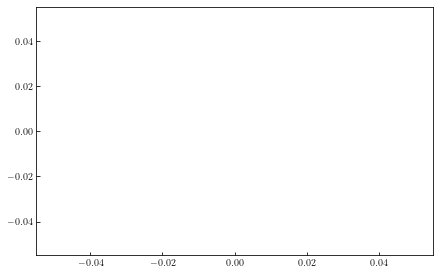

In [33]:
import matplotlib.pyplot as plt 
plt.plot()
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 10,
    "font.family" : "serif",
    'figure.constrained_layout.use':True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'hatch.linewidth':0.1,
    'figure.figsize': (6, 6/1.618),
    'figure.constrained_layout.use': True,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'text.latex.preamble' : r'\usepackage{amsmath}',
})


# consistent with fourier transform of polynomial kernels being dominated by 1/k term

Text(0.005, 0.15, '\\textsc{TMP:Noise Dom.}')

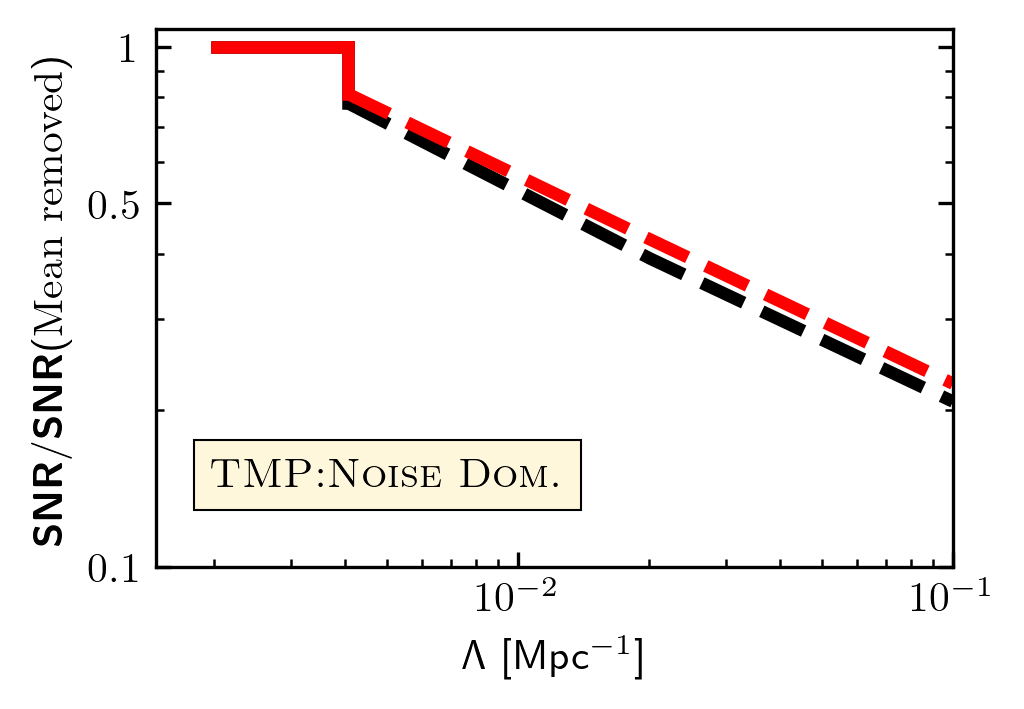

In [42]:
plt.figure(figsize = (3.3, 2.25), facecolor = 'w', dpi = 300)
xmin = Lambdas[13]

experiment = 'CHIME'
#metadata
zmin = experiments[experiment]['zmin']
zmax = experiments[experiment]['zmax']
line_str = experiments[experiment]['line_str']

Omega_field  =  np.array(experiments[experiment]['Omega_field'].to(u.rad**2)) #rad^2
chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))

kpar_fundamental = 2*np.pi/(chimax - chimin)

ell_fundamental = np.sqrt((2*np.pi)**2 / Omega_field)
ell_fundamental = max(np.array(ell_fundamental), 10)

ell_max_survey = np.sqrt((np.pi)**2 / experiments[experiment]['Omega_pix'].to(u.rad**2).value)
ell_max_survey = np.array(ell_max_survey)

_Lambdas = Lambdas[experiments[experiment]['Lambda_idxs']]

plot_SNR(list(CHIME_SNR.values())/list(CHIME_SNR.values())[1], kpar_fundamental, plt.gca(), c='k')
plot_SNR(list(CHIME_SNR_supLin.values())/list(CHIME_SNR_supLin.values())[1], kpar_fundamental, plt.gca(), c='r')

ax = plt.gca()


# axes
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin, 1e-1)
# plt.ylim(5e-2, 3e1)
plt.ylabel(r'\textsf{\textbf{SNR}}/\textsf{\textbf{SNR}(\textrm{Mean removed})}')
plt.xlabel(r'${\sf \Lambda}$ \sf[Mpc${}^{-1}$]')




# hline_text(x=xmin*np.exp(0.1), y=detect_thresh, text=r'\textsf{\textbf{Detectibility Threshold}}', lw=1,
#            color='k', fontsize=11, linestyle='-',
#            ha = 'left', pad=0.009)

ax.tick_params(axis='y', which='both', right=True, zorder=10)

ax.set_yticks([1, 0.5, 0.1])
ax.set_yticklabels([1, 0.5, 0.1])



plt.text(x=5e-3, y=0.15,#x = 1.13e-1, y= ax.get_ylim()[-1], 
     s=r'\textsc{TMP:Noise Dom.}',
     horizontalalignment='center',
     fontsize=10,
     bbox=dict(facecolor=(1, 0.8, 0.0, 0.14),
               lw=0.5,
               edgecolor='k'),
     verticalalignment='center')